In [173]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import netcdf
import netCDF4 as nc
# fname 为 你下载的字体库路径，注意 SourceHanSansSC-Bold.otf 字体的路径
import matplotlib
zhfont1 = matplotlib.font_manager.FontProperties(fname=r"/home/zhangzhibo/font/SourceHanSansSC-Bold.otf") 


In [174]:
file_path_base = r'/home/zhangzhibo/serghei/serghei-20240910-RTM/tests/t5-dispersion/'
subsurface_file_path = file_path_base + r'out-555/output_subsurface.nc'
subsurface_dataset =  nc.Dataset(subsurface_file_path, 'r') # 'r' 表示只读模式
z_out = subsurface_dataset.variables['z3d'][:]
wc_out = subsurface_dataset.variables['wc'][:]
h_out = subsurface_dataset.variables['hd'][:]
qx_out = subsurface_dataset.variables['qx'][:]
qy_out = subsurface_dataset.variables['qy'][:]
qz_out = subsurface_dataset.variables['qz'][:]
t_out = subsurface_dataset.variables['t'][:]
subsurface_dataset

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    dimensions(sizes): t(4), x(1), y(1), z(200)
    variables(dimensions): float64 t(t), float64 x(x), float64 y(y), float64 z(z), float64 z3d(z, y, x), float64 hd(t, z, y, x), float64 wc(t, z, y, x), float64 qx(t, z, y, x), float64 qy(t, z, y, x), float64 qz(t, z, y, x)
    groups: 

In [175]:
# 打开NetCDF文件
file_path = file_path_base + r'out-111/output_transport.nc'
dataset = nc.Dataset(file_path, 'r')
c_out = dataset.variables['c'][:]
cs_out = dataset.variables['c_solid'][:]
file_path2 = file_path_base + r'out-222/output_transport.nc'
dataset2 = nc.Dataset(file_path2, 'r')
c_out2 = dataset2.variables['c'][:]
cs_out2 = dataset2.variables['c_solid'][:]
file_path3 = file_path_base + r'out-333/output_transport.nc'
dataset3 = nc.Dataset(file_path3, 'r')
c_out3 = dataset3.variables['c'][:]
cs_out3 = dataset3.variables['c_solid'][:]
file_path4 = file_path_base + r'out-444/output_transport.nc'
dataset4 = nc.Dataset(file_path4, 'r')
c_out4 = dataset4.variables['c'][:]
cs_out4 = dataset4.variables['c_solid'][:]
file_path5 = file_path_base + r'out-555/output_transport.nc'
dataset5 = nc.Dataset(file_path5, 'r')
c_out5 = dataset5.variables['c'][:]
cs_out5 = dataset5.variables['c_solid'][:]
dataset



<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    dimensions(sizes): t(101), x(1), y(1), z(200)
    variables(dimensions): float64 t(t), float64 x(x), float64 y(y), float64 z(z), float64 z3d(z, y, x), float64 c(t, z, y, x), float64 c_solid(t, z, y, x), float64 c_difxz(t, z, y, x), float64 c_difzx(t, z, y, x), float64 c_difxx(t, z, y, x), float64 c_difzz(t, z, y, x)
    groups: 

In [176]:
print("t=0",np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:])),
print("t=1",np.sum (c_out[1,:,:,:]*wc_out[1,:,:,:])),
print("t=-1",np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])),
print("t=-2 - t=-1",np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[-2,:,:,:]*wc_out[-2,:,:,:]))
print("precent",(np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))/np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))

t=0 0.0
t=1 15.584607889096759
t=-1 811.1201237001387
t=-2 - t=-1 4.24597249397732
precent inf


/tmp/ipykernel_26971/2326341391.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  print("precent",(np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))/np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))


质量守恒分析

In [177]:
np.sum(c_out[-1,:,:,:])
c_out5[:,0,0,0]

masked_array(data=[10., 10., 10., 10.],
             mask=False,
       fill_value=1e+20)

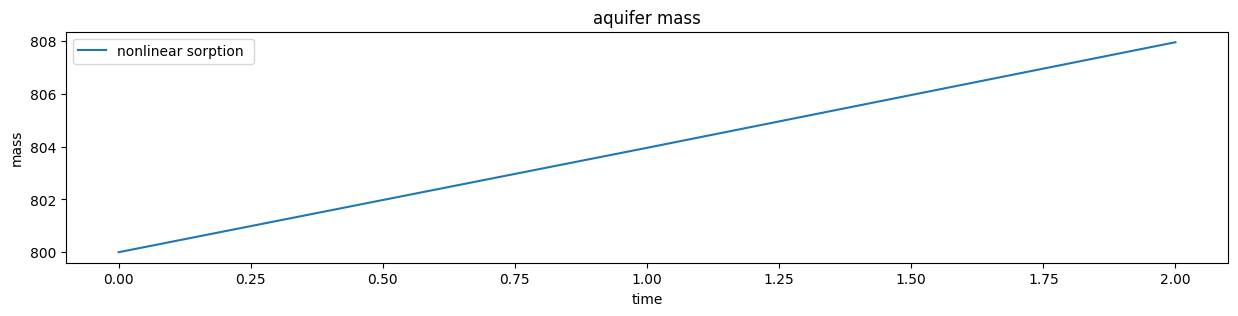

In [178]:
mass =[]
# for i in range(0,20):
#      mass.append(np.sum (c_out[i,:,:,:]*wc_out[i,:,:,:]))
mass2 =[]
# for i in range(0,20):
     # mass2.append(np.sum (c_out2[i,:,:,:]*wc_out[i,:,:,:]))
# mass3 =[]
# for i in range(0,20):
#      mass3.append(np.sum (c_out3[i,:,:,:]*wc_out[i,:,:,:]))
# mass4 =[]
# for i in range(0,20):
#      mass4.append(np.sum (c_out4[i,:,:,:]*wc_out[i,:,:,:]))
mass5 =[]
for i in range(0,c_out5.shape[0]-1):
     mass5.append(np.sum (c_out5[i,:,:,:]*wc_out[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
# plt.plot(mass[:],label='no sorption')
# plt.plot(mass2[:],label='linearly sorption Rf = 5')
# plt.plot(mass3[:],label='decay lambda =  2.31e-8 ',linestyle='--')
# plt.plot(mass4[:],label='advection' )
plt.plot(mass5[:],label='nonlinear sorption ')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('aquifer mass')
plt.legend()
plt.xlabel('time')
plt.ylabel('mass')
plt.show()

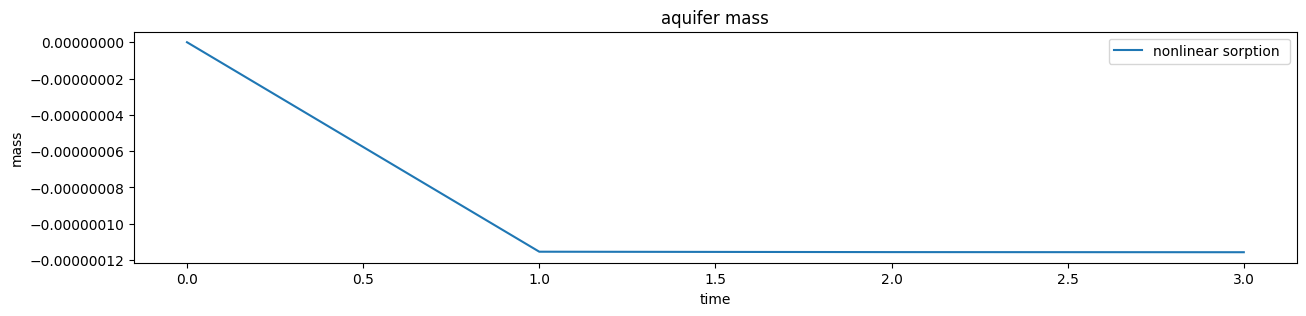

In [179]:
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(qz_out[:,0,0,0],label='nonlinear sorption ')

plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('aquifer mass')
plt.legend()
plt.xlabel('time')
plt.ylabel('mass')
plt.show()

固相质量守恒

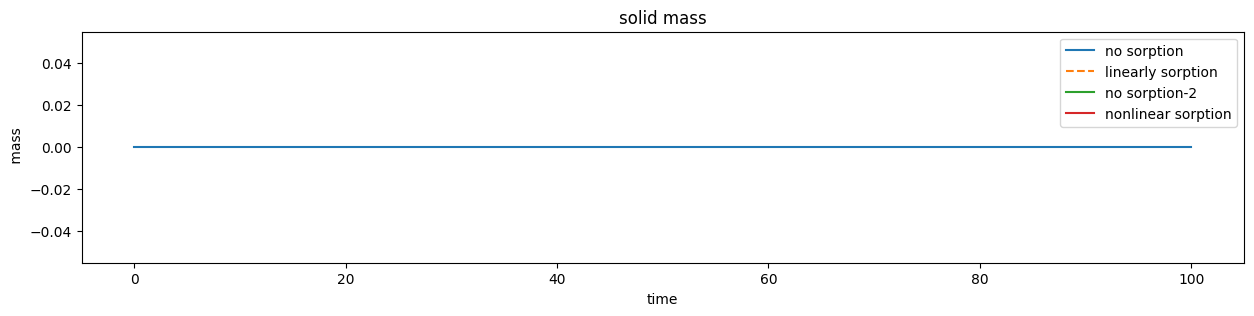

In [7]:
mass =[]
for i in range(0,cs_out.shape[0]):
     mass.append(np.sum (cs_out[i,:,:,:]))
mass2 =[]
# for i in range(0,cs_out2.shape[0]):
     # mass2.append(np.sum (cs_out2[i,:,:,:]))
mass3 =[]
# for i in range(0,c_out3.shape[0]):
#      mass3.append(np.sum (c_out3[i,:,:,:]*wc_out[i,:,:,:]))
# mass4 =[]
# for i in range(0,c_out4.shape[0]):
#      mass4.append(np.sum (c_out4[i,:,:,:]*wc_out[i,:,:,:]))
mass5 =[]
# for i in range(0,c_out5.shape[0]):
     # mass5.append(np.sum (c_out5[i,:,:,:]*wc_out[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(mass[:],label='no sorption')
plt.plot(mass2[:],label='linearly sorption',linestyle='--')
plt.plot(mass3[:],label='no sorption-2')
# plt.plot(mass4[:],label='linearly sorption-2') 
plt.plot(mass5[:],label='nonlinear sorption')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('solid mass')
plt.legend()
plt.xlabel('time')
plt.ylabel(' mass')
plt.show()

水相+固相

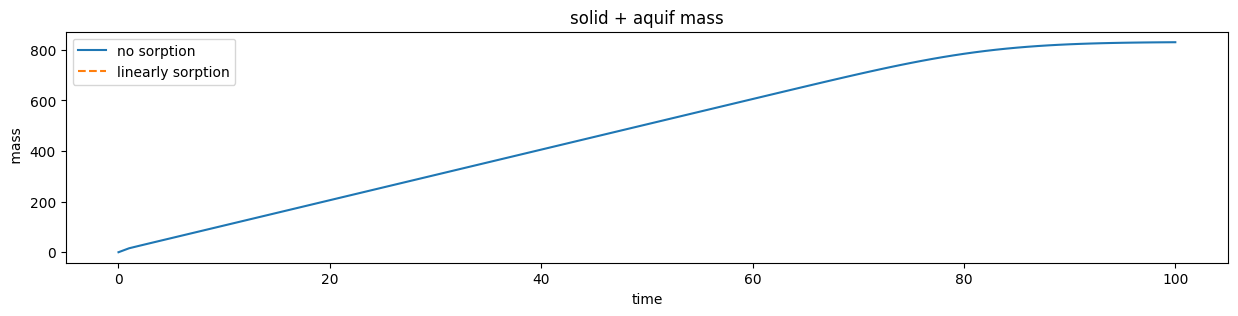

In [8]:
mass =[]
for i in range(0,cs_out.shape[0]):
     mass.append(np.sum (c_out[i,:,:,:]*wc_out[i,:,:,:]+cs_out[i,:,:,:]))
# mass2 =[]
# for i in range(0,cs_out2.shape[0]):
#      mass2.append(np.sum (c_out2[i,:,:,:]*wc_out[i,:,:,:]+cs_out2[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(mass[:],label='no sorption')
plt.plot(mass2[:],label='linearly sorption',linestyle='--')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('solid + aquif mass')
plt.legend()
plt.xlabel('time')
plt.ylabel(' mass')
plt.show()

In [9]:
t=c_out5.shape[0]-1
# t = 20
# t=40
# t = 60

<function matplotlib.pyplot.show(close=None, block=None)>

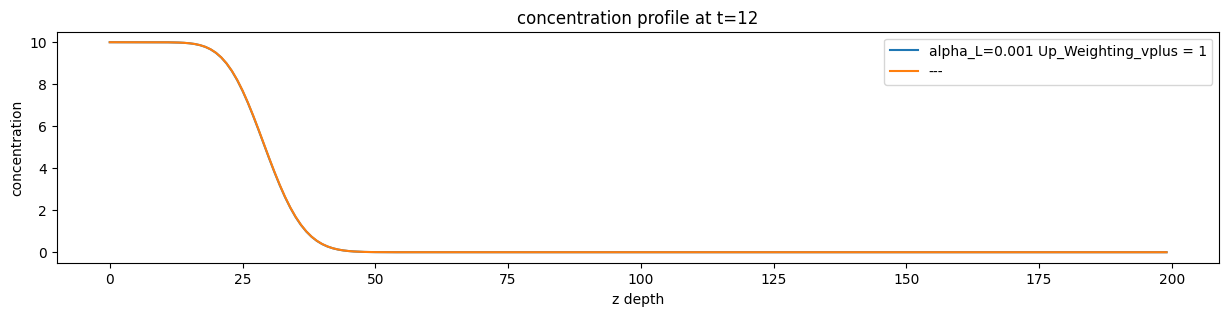

In [10]:
# t = 5
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
# plt.plot(c_out[t,:,0,0],label='alpha_L=0.01 Up_Weighting_vplus = 0.5')
# plt.plot(c_out2[t,:,0,0],label='alpha_L=0.1 Up_Weighting_vplus = 0.5')
# plt.plot(c_out3[t,:,0,0],label='alpha_L=0.001 Up_Weighting_vplus = 0.5')
plt.plot(c_out4[t,:,0,0],label='alpha_L=0.001 Up_Weighting_vplus = 1')
plt.plot(c_out5[t,:,0,0],label='---')
plt.xlabel('z depth')
plt.ylabel('concentration')
plt.title('concentration profile at t='+str(t))
plt.legend()
plt.show

In [108]:
np.max(c_out3[t,:,0,0])

np.float64(10.27960855558818)

In [112]:
data_to_save = np.column_stack((z_out[:, 0, 0], c_out4[t, :, 0, 0]))
np.savetxt('c_out.txt',data_to_save,delimiter=' ',fmt='%.4e' )

<function matplotlib.pyplot.show(close=None, block=None)>

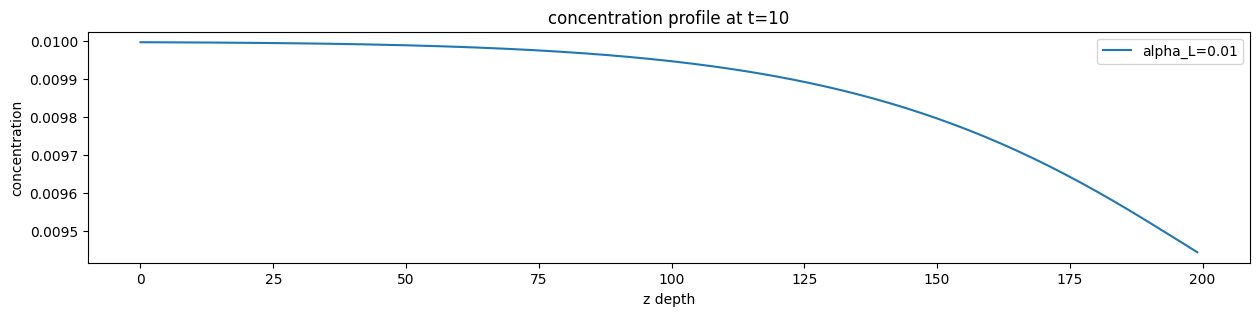

In [5]:
t = 10
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(qz_out[t,:,0,0]*86400*(-1),label='alpha_L=0.01')
# plt.plot(c_out2[t,:,0,0],label='alpha_L=0.1',linestyle='--')
# plt.plot(c_out3[t,:,0,0],label='frundlich sorption')
# plt.plot(c_out4[t,:,0,0],label='langmuir sorption')
# plt.plot(c_out5[t,:,0,0],label='---')
plt.xlabel('z depth')
plt.ylabel('concentration')
plt.title('concentration profile at t='+str(t))
plt.legend()
plt.show

In [6]:
data = qz_out[t,:,0,0]*86400*(-1)
data[-10:]

masked_array(data=[0.00952295, 0.00951438, 0.00950576, 0.00949709,
                   0.00948839, 0.00947963, 0.00947092, 0.00946195,
                   0.00945377, 0.00944516],
             mask=False,
       fill_value=1e+20)

固定点位浓度时间图

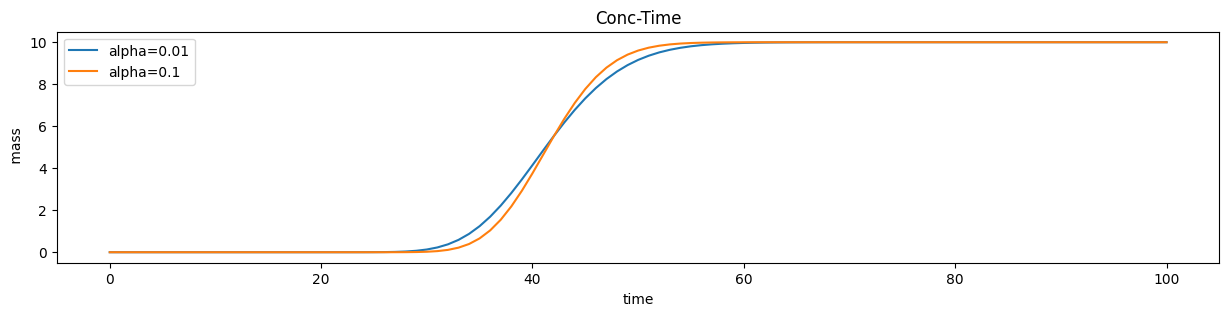

In [113]:

plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(c_out[:,100,0,0],label='alpha=0.01')
plt.plot(c_out4[:,100,0,0],label='alpha=0.1')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('Conc-Time')
plt.legend()
plt.xlabel('time')
plt.ylabel(' mass')
plt.show()

In [41]:
c_out2.shape

(101, 200, 1, 1)

In [114]:
data_to_save = np.column_stack((t_out[:], c_out4[:,100,0,0]))
np.savetxt('c-time-out.txt',data_to_save,delimiter=' ',fmt='%.4e' )